# Factor Analysis

# Import necessary libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.decomposition import FactorAnalysis 
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity, calculate_kmo 

# Load dataset

In [3]:
maize_data = pd.read_csv('maize_data_factor.csv')
maize_data.head()

,Genotypes,FT,PH,KRPC,KPR,CL,CW,1000K,SH,KYPP
0,CML-269,72.00,188.4,14.40,32.20,15.37,82.13,200.00,64.59,102.28
1,CML-296,73.00,148.0,13.73,25.53,12.53,69.13,206.67,80.13,129.41
2,CML-298,75.00,157.0,12.00,27.07,13.85,82.53,190.00,70.58,39.73
3,CML-307,79.00,100.0,12.80,18.53,11.63,46.53,160.00,68.87,45.60
4,CML-482,71.33,189.0,12.67,19.00,15.37,70.27,223.33,71.41,70.40


# Select the dataframe for factor analysis

In [5]:
# select the dataframe for cluster analysis
data = maize_data.iloc[:, 1:10]
data.head()

,FT,PH,KRPC,KPR,CL,CW,1000K,SH,KYPP
0,72.00,188.4,14.40,32.20,15.37,82.13,200.00,64.59,102.28
1,73.00,148.0,13.73,25.53,12.53,69.13,206.67,80.13,129.41
2,75.00,157.0,12.00,27.07,13.85,82.53,190.00,70.58,39.73
3,79.00,100.0,12.80,18.53,11.63,46.53,160.00,68.87,45.60
4,71.33,189.0,12.67,19.00,15.37,70.27,223.33,71.41,70.40


# Assign cluster labels from dataset

In [7]:
# Assign cluster labels from dataset
d = maize_data.iloc[:, 0]
columns = ['FT','PH','KRPC','KPR','CL','CW','1000K', 'SH', 'KYPP']

# Create DataFrame

In [9]:
# Create DataFrame
df = pd.DataFrame(data, columns=columns)

# Univariate description

In [11]:
# Univariate description
print("Univariate Description:")
print(df.describe())

Univariate Description:
              FT          PH       KRPC        KPR         CL         CW  \
count  40.000000   40.000000  40.000000  40.000000  40.000000  40.000000   
mean   74.058750  155.110000  13.182250  22.529000  13.996000  54.179000   
std     4.337913   23.403044   0.922262   4.385074   1.511847  18.064335   
min    65.000000  100.000000  11.600000  16.000000  10.890000  21.600000   
25%    71.330000  136.300000  12.670000  18.785000  13.037500  40.352500   
50%    73.500000  156.100000  13.070000  22.065000  14.160000  56.335000   
75%    76.670000  175.050000  13.600000  25.285000  15.105000  66.850000   
max    82.670000  205.600000  15.600000  32.270000  17.690000  98.130000   

            1000K         SH        KYPP  
count   40.000000  40.000000   40.000000  
mean   201.359000  70.236750   60.762500  
std     23.946845   5.814806   25.374584  
min    137.670000  58.530000   39.330000  
25%    186.670000  67.952500   44.330000  
50%    200.000000  70.975000   50

# Correlation matrix

In [13]:
# Correlation matrix
print("\nCorrelation Matrix:")
corr_matrix = df.corr()
print(corr_matrix)


Correlation Matrix:
             FT        PH      KRPC       KPR        CL        CW     1000K  \
FT     1.000000 -0.382091  0.079629 -0.229084 -0.191178 -0.367089 -0.366913   
PH    -0.382091  1.000000 -0.098787  0.343331  0.234315  0.215905  0.282877   
KRPC   0.079629 -0.098787  1.000000  0.248037  0.083034  0.149005  0.140768   
KPR   -0.229084  0.343331  0.248037  1.000000  0.381116  0.490277  0.203772   
CL    -0.191178  0.234315  0.083034  0.381116  1.000000  0.683115  0.316682   
CW    -0.367089  0.215905  0.149005  0.490277  0.683115  1.000000  0.282957   
1000K -0.366913  0.282877  0.140768  0.203772  0.316682  0.282957  1.000000   
SH    -0.094822  0.138876 -0.120113  0.255857 -0.026943  0.263686  0.041014   
KYPP  -0.167604  0.145158  0.267817  0.536995  0.373043  0.590268  0.134317   

             SH      KYPP  
FT    -0.094822 -0.167604  
PH     0.138876  0.145158  
KRPC  -0.120113  0.267817  
KPR    0.255857  0.536995  
CL    -0.026943  0.373043  
CW     0.263686  0.5

# Plot correlation matrix

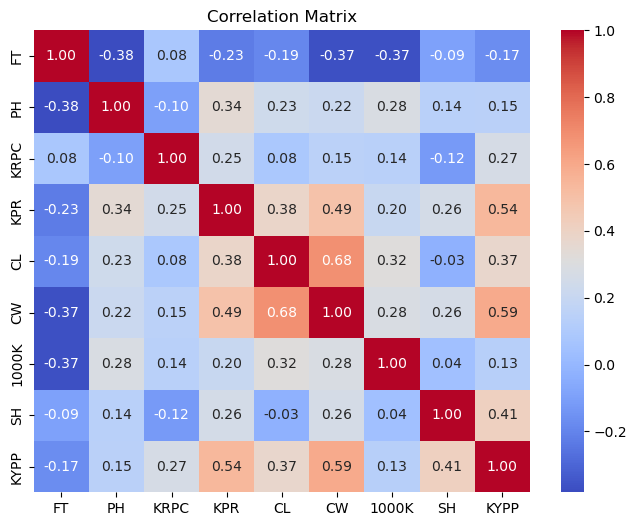

In [15]:
# Plot correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 10})
plt.title("Correlation Matrix")
plt.show()

# Apply Bartlett's test of sphericity to check the suitability for factor analysis

In [17]:
# Apply Bartlett's test of sphericity to check the suitability for factor analysis
chi_square_value, p_value = calculate_bartlett_sphericity(df)
print(f"Bartlett's Test Chi-Square Value: {chi_square_value}")
print(f"Bartlett's Test P-Value: {p_value}")

Bartlett's Test Chi-Square Value: 95.50877859095911
Bartlett's Test P-Value: 2.733497667141752e-07


# Apply Kaiser-Meyer-Olkin (KMO) test to measure sampling adequacy

In [19]:
# Apply Kaiser-Meyer-Olkin (KMO) test to measure sampling adequacy
kmo_all, kmo_model = calculate_kmo(df)
print(f"KMO Test Score: {kmo_model}")

KMO Test Score: 0.665212089841791


# Check Eigenvalues to determine the number of factors

In [21]:
# Check Eigenvalues to determine the number of factors
fa = FactorAnalyzer(n_factors=len(columns), rotation=None)
fa.fit(df)

FactorAnalyzer(n_factors=9, rotation=None, rotation_kwargs={})

# Get Eigenvalues

In [23]:
# Get Eigenvalues
eigenvalues, _ = fa.get_eigenvalues()

# Create labels for the factors
factor_labels = [f'Factor_{i+1}' for i in range(len(eigenvalues))]

# Print Eigenvalues with Factor Labels
eigenvalues_df = pd.DataFrame({'Factor': factor_labels, 'Eigenvalue': eigenvalues})
print(f"Eigenvalues with Factor Labels:\n{eigenvalues_df}")

Eigenvalues with Factor Labels:
     Factor  Eigenvalue
0  Factor_1    3.177554
1  Factor_2    1.376043
2  Factor_3    1.217660
3  Factor_4    0.890716
4  Factor_5    0.741993
5  Factor_6    0.619201
6  Factor_7    0.427453
7  Factor_8    0.341268
8  Factor_9    0.208113


# Plot Eigenvalues (Scree Plot)

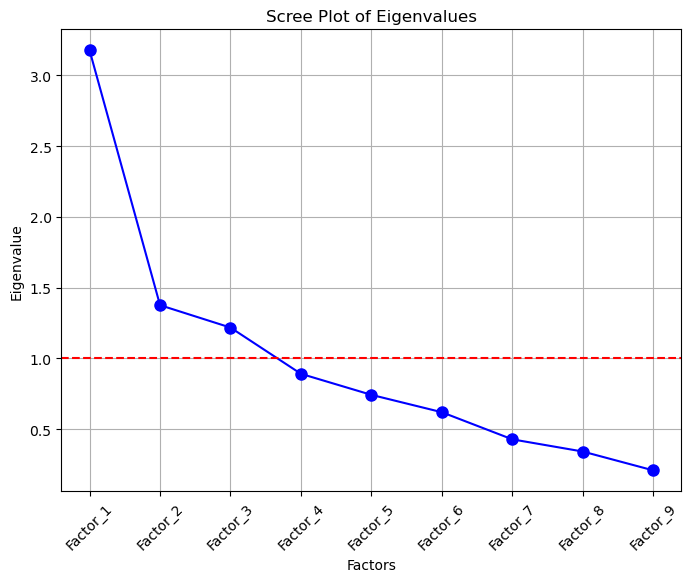

In [25]:
# Plot Eigenvalues (Scree Plot)
plt.figure(figsize=(8, 6))
plt.plot(factor_labels, eigenvalues, 'o-', markersize=8, color='b')
plt.title('Scree Plot of Eigenvalues')
plt.xlabel('Factors')
plt.ylabel('Eigenvalue')
plt.axhline(y=1, color='r', linestyle='--')  # Threshold for retaining factors (Eigenvalue > 1)
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.grid(True)
plt.show()

# Based on Eigenvalues, let's choose the number of factors (e.g., 3 factors)

In [27]:
# Based on Eigenvalues, let's choose the number of factors (e.g., 3 factors)
n_factors = 3

# Perform factor analysis with the determined number of factors

In [29]:
from factor_analyzer import FactorAnalyzer

# Perform factor analysis with the determined number of factors
fa = FactorAnalyzer(n_factors=n_factors, rotation="varimax")
fa.fit(df)

FactorAnalyzer(rotation='varimax', rotation_kwargs={})

# Get factor loadings

In [31]:
# Get factor loadings
factor_loadings = fa.loadings_
# Create a DataFrame for better readability, including the variable names and factor labels
factor_names = [f'Factor_{i+1}' for i in range(n_factors)]  # Create factor names
factor_loadings_df = pd.DataFrame(factor_loadings, index=columns, columns=factor_names)
# Print the DataFrame with factor loadings
print(f"Factor Loadings with Labels:\n{factor_loadings_df}")

Factor Loadings with Labels:
       Factor_1  Factor_2  Factor_3
FT    -0.035039 -0.649571 -0.095423
PH     0.016369  0.580702  0.147912
KRPC   0.401645 -0.121408 -0.077836
KPR    0.507589  0.304600  0.296029
CL     0.601188  0.405064 -0.078326
CW     0.683361  0.430886  0.219999
1000K  0.190317  0.480777 -0.045621
SH     0.015546  0.080436  0.790907
KYPP   0.668340  0.092464  0.509031


# Get the variance of each factor

In [33]:
# Get the variance of each factor
variance = fa.get_factor_variance()

# Variance details
factor_variance = variance[0]  # Variance explained by each factor
proportional_variance = variance[1]  # Proportional variance explained by each factor
cumulative_variance = variance[2]  # Cumulative variance explained by the factors

# Print the variance results with labels
factor_names = [f'Factor_{i+1}' for i in range(len(factor_variance))]

# Display the results in a tabular format
variance_df = pd.DataFrame({
    'Factor': factor_names,
    'Variance': factor_variance,
    'Proportional Variance': proportional_variance,
    'Cumulative Variance': cumulative_variance
})

print("\nFactor Variances:")
print(variance_df)


Factor Variances:
     Factor  Variance  Proportional Variance  Cumulative Variance
0  Factor_1  1.732011               0.192446             0.192446
1  Factor_2  1.462584               0.162509             0.354955
2  Factor_3  1.065937               0.118437             0.473392


# Get the factor score for each genotypes

In [35]:
# Get the Genotype column to use as labels
genotype_labels = maize_data['Genotypes']  # Assuming the Genotype column exists in maize_data
# Get factor scores for each data point
factor_scores = fa.transform(df)
# Create labels for the factors
factor_labels = [f'Factor_{i+1}' for i in range(n_factors)]
# Create a DataFrame with the factor scores and include genotype labels
factor_scores_df = pd.DataFrame(factor_scores, columns=factor_labels)
# Add the Genotype labels to the DataFrame
factor_scores_df['Genotypes'] = genotype_labels
# Reorder columns to display Genotype first
factor_scores_df = factor_scores_df[['Genotypes'] + factor_labels]

# Ensure that all rows are displayed
pd.set_option('display.max_rows', None)  # Set this to None to display all rows
# Display the factor scores DataFrame with genotype labels
print(f"\nFactor Scores with Genotype Labels:\n{factor_scores_df}")


Factor Scores with Genotype Labels:
         Genotypes  Factor_1  Factor_2  Factor_3
0          CML-269  1.908368  0.690402 -0.198295
1          CML-296  1.047802 -0.530155  2.055821
2          CML-298  0.217904  0.481459 -0.099242
3          CML-307 -0.396312 -1.702113 -0.104165
4          CML-482  0.186783  1.072971  0.076476
5           CM-111  0.431296  0.375899 -0.187846
6           CM-135 -1.300181  0.884395 -0.228073
7           CM-140 -1.665564  0.184601  0.720725
8         CM-212-2 -0.691492 -1.307456 -0.134838
9        CM- 500-1 -0.164620  0.221797  1.044847
10        CM-500-2  0.023378 -0.794271 -0.010550
11           GYL-1 -0.928437  1.453305  0.018317
12           GYL-2 -0.847050  0.945320 -0.118036
13           GYL-4  0.685070  0.756209  1.400967
14           GYL-5 -0.710687 -0.231125  0.075635
15           GYL-6 -0.922693  0.276871 -1.361246
16           GYL-7 -0.305198 -0.809135  1.649805
17           GYL-8  0.031416  0.905706  0.604014
18           GYL-9  0.228044 -0.

# Factor biplot

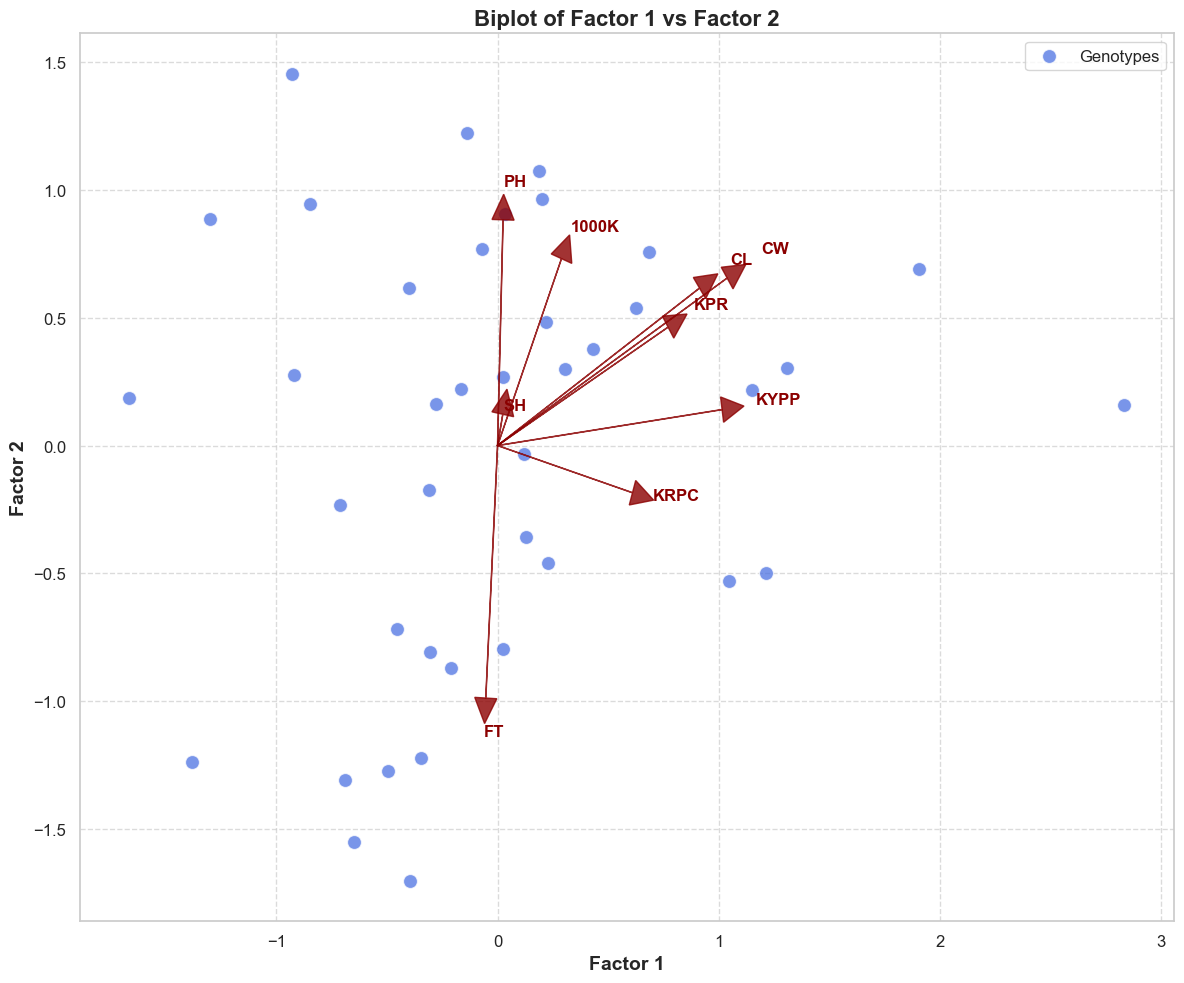

In [37]:
# Calculate the maximum length of feature vectors for normalization
loadings = fa.loadings_
norms = np.linalg.norm(loadings, axis=0)
max_norm = np.max(norms)

# Define a scaling factor to increase the size of the feature vectors
scaling_factor = 2  # Adjust this value to increase the size of the feature vectors

# Set plot style and aesthetics
sns.set(style="whitegrid")  # Set a clean style
plt.figure(figsize=(12, 10))

# Scatter plot for Factor 1 vs Factor 2
sns.scatterplot(x='Factor_1', y='Factor_2', data=factor_scores_df, color='royalblue', s=100, edgecolor='w', alpha=0.7)

# Add scaled feature vectors
for i, feature in enumerate(columns):
    # Normalize and scale the vectors
    x = (loadings[i, 0] / max_norm) * scaling_factor
    y = (loadings[i, 1] / max_norm) * scaling_factor
    plt.arrow(0, 0, x, y, head_width=0.1, head_length=0.1, fc='darkred', ec='darkred', alpha=0.8)
    plt.text(x * 1.15, y * 1.15, feature, color='darkred', fontsize=12, weight='bold')

# Add labels to the plot
plt.title('Biplot of Factor 1 vs Factor 2', fontsize=16, weight='bold')
plt.xlabel('Factor 1', fontsize=14, weight='bold')
plt.ylabel('Factor 2', fontsize=14, weight='bold')

# Customize ticks
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Show grid with customized style
plt.grid(True, linestyle='--', alpha=0.7)

# Add a legend
plt.legend(['Genotypes'], loc='best', fontsize=12)

# Show the plot
plt.tight_layout()
plt.show()